# 04 Embedding Feature MLP Confidence Classification

## 목적

이전 `confidence 분류기 5-17실험`과 비교할 수 있도록 입력 feature 구성을 맞춘다.

이번 노트북에서는 `audio embedding + text embedding + class one-hot + similarity/margin feature`를 입력으로 사용해 두 모델을 학습한다.

## 모델 1. 5-class confidence classification

```text
target = confidence 1,2,3,4,5
```

평가:

- Accuracy
- Precision
- Recall
- F1
- MAE
- Confusion Matrix
- Train loss / Validation loss
- Classification Report for confidence 1,2,3,4,5

## 모델 2. Binary high-confidence classification

```text
confidence 1,2,3 -> 0
confidence 4,5   -> 1
```

평가:

- Accuracy
- Precision
- Recall
- F1
- MAE
- Confusion Matrix
- Train loss / Validation loss
- Classification Report for 123 vs 45

## 입력 feature

기본 입력 feature는 이전 MLP 실험과 비교 가능하도록 아래처럼 구성한다.

```text
audio embedding 512
text embedding 512
class one-hot 23
audio_text_sim 1
audio_class_sim 1
audio_assigned_label_margin 1
text_assigned_label_margin 1
total 1051
```

모든 output은 `deft논문기반_실험/mlp_embedding_plus_similarity_confidence_outputs/` 안에 저장한다.

In [1]:
from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HERE = Path.cwd()
if (HERE / '실험계획.md').exists():
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

METADATA_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
TEXT_SIM_CSV = EXP_DIR / 'audio_text_sim_confidence_outputs' / 'audio_text_similarity_with_bin_predictions.csv'
CLASS_SIM_CSV = EXP_DIR / 'audio_class_sim_confidence_outputs' / 'audio_class_similarity_with_bin_predictions.csv'
MARGIN_CSV = EXP_DIR / 'clap_similarity_margin_outputs' / 'clap_similarity_margin_features.csv'

OUT_DIR = EXP_DIR / 'mlp_embedding_plus_similarity_confidence_outputs'
PLOT_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('ROOT:', ROOT)
print('EXP_DIR:', EXP_DIR)
print('OUT_DIR:', OUT_DIR)
print('DEVICE:', DEVICE)
print('METADATA_CSV exists:', METADATA_CSV.exists())
print('AUDIO_EMB_DIR exists:', AUDIO_EMB_DIR.exists())
print('TEXT_EMB_DIR exists :', TEXT_EMB_DIR.exists())
print('TEXT_SIM_CSV exists :', TEXT_SIM_CSV.exists())
print('CLASS_SIM_CSV exists:', CLASS_SIM_CSV.exists())
print('MARGIN_CSV exists   :', MARGIN_CSV.exists())

ROOT: c:\Users\solok\Desktop\Dcase baseline
EXP_DIR: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험
OUT_DIR: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\mlp_embedding_plus_similarity_confidence_outputs
DEVICE: cuda
METADATA_CSV exists: True
AUDIO_EMB_DIR exists: True
TEXT_EMB_DIR exists : True
TEXT_SIM_CSV exists : True
CLASS_SIM_CSV exists: True
MARGIN_CSV exists   : True


## 1. Embedding feature 로드

`data/features/clap_audio_embeddings`, `data/features/clap_text_embeddings`에서 직접 embedding을 읽고 metadata의 class를 one-hot으로 변환한다. 여기에 01/02/03 노트북에서 만든 similarity/margin scalar feature 4개를 추가한다.

In [2]:
LABELS = [1, 2, 3, 4, 5]
SCALAR_FEATURE_COLS = [
    'audio_text_sim',
    'audio_class_sim',
    'audio_assigned_label_margin',
    'text_assigned_label_margin',
]
FEATURE_DESCRIPTION = 'audio_embedding_512 + text_embedding_512 + class_one_hot + similarity_margin_4'

meta = pd.read_csv(METADATA_CSV)
required_cols = ['sound_id', 'class', 'confidence']
missing_cols = [c for c in required_cols if c not in meta.columns]
if missing_cols:
    raise ValueError(f'metadata에 필요한 컬럼이 없습니다: {missing_cols}')

audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}

rows = []
audio_list = []
text_list = []
missing_audio = 0
missing_text = 0
invalid_confidence = 0

for _, row in meta.iterrows():
    sound_id = str(row['sound_id'])
    audio_path = audio_paths.get(sound_id)
    text_path = text_paths.get(sound_id)
    if audio_path is None:
        missing_audio += 1
        continue
    if text_path is None:
        missing_text += 1
        continue
    try:
        confidence = int(row['confidence'])
    except Exception:
        invalid_confidence += 1
        continue
    if confidence not in LABELS:
        invalid_confidence += 1
        continue

    audio = np.load(audio_path).astype(np.float32).reshape(-1)
    text = np.load(text_path).astype(np.float32).reshape(-1)
    if audio.shape[0] != text.shape[0]:
        raise ValueError(f'embedding dimension mismatch: sound_id={sound_id}, audio={audio.shape}, text={text.shape}')

    audio_list.append(audio)
    text_list.append(text)
    rows.append({
        'sound_id': sound_id,
        'class': str(row['class']).strip(),
        'confidence': confidence,
    })

df = pd.DataFrame(rows)
df['_row_idx'] = np.arange(len(df))
audio_emb = np.stack(audio_list).astype(np.float32)
text_emb = np.stack(text_list).astype(np.float32)

text_sim_df = pd.read_csv(TEXT_SIM_CSV)[['sound_id', 'audio_text_sim']]
class_sim_df = pd.read_csv(CLASS_SIM_CSV)[['sound_id', 'audio_class_sim']]
margin_df = pd.read_csv(MARGIN_CSV)[['sound_id', 'audio_assigned_label_margin', 'text_assigned_label_margin']]
for part_df in [text_sim_df, class_sim_df, margin_df]:
    part_df['sound_id'] = part_df['sound_id'].astype(str)

df = df.merge(text_sim_df, on='sound_id', how='left')
df = df.merge(class_sim_df, on='sound_id', how='left')
df = df.merge(margin_df, on='sound_id', how='left')
missing_scalar = df[SCALAR_FEATURE_COLS].isna().any(axis=1).sum()
df = df.dropna(subset=SCALAR_FEATURE_COLS).reset_index(drop=True)

keep_idx = df['_row_idx'].to_numpy(dtype=np.int64)
audio_emb = audio_emb[keep_idx]
text_emb = text_emb[keep_idx]
scalar_features = df[SCALAR_FEATURE_COLS].to_numpy(dtype=np.float32)

class_categories = sorted(df['class'].unique().tolist())
class_to_idx = {name: idx for idx, name in enumerate(class_categories)}
class_ids = df['class'].map(class_to_idx).to_numpy(dtype=np.int64)
class_onehot = np.eye(len(class_categories), dtype=np.float32)[class_ids]

X_full = np.concatenate([audio_emb, text_emb, class_onehot, scalar_features], axis=1).astype(np.float32)
df['class_idx'] = class_ids
df['binary_confidence'] = (df['confidence'] >= 4).astype(int)
df = df.drop(columns=['_row_idx'])

df.to_csv(OUT_DIR / 'embedding_plus_similarity_mlp_dataset_index.csv', index=False, encoding='utf-8-sig')
np.save(OUT_DIR / 'X_audio_text_class_similarity_margin.npy', X_full)
(OUT_DIR / 'class_mapping.json').write_text(json.dumps(class_to_idx, indent=2, ensure_ascii=False), encoding='utf-8')

print('rows:', len(df))
print('missing audio:', missing_audio)
print('missing text:', missing_text)
print('invalid confidence:', invalid_confidence)
print('missing scalar features:', missing_scalar)
print('audio_emb shape:', audio_emb.shape)
print('text_emb shape:', text_emb.shape)
print('class_onehot shape:', class_onehot.shape)
print('scalar_features shape:', scalar_features.shape)
print('X_full shape:', X_full.shape)
display(df[['sound_id', 'class', 'class_idx', 'confidence', 'binary_confidence'] + SCALAR_FEATURE_COLS].head())
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())
display(df['binary_confidence'].value_counts().sort_index().rename('count').to_frame())

rows: 10956
missing audio: 0
missing text: 0
invalid confidence: 0
missing scalar features: 0
audio_emb shape: (10956, 512)
text_emb shape: (10956, 512)
class_onehot shape: (10956, 23)
scalar_features shape: (10956, 4)
X_full shape: (10956, 1051)


,sound_id,class,class_idx,confidence,binary_confidence,audio_text_sim,audio_class_sim,audio_assigned_label_margin,text_assigned_label_margin
0,185755,fx-o,6,4,1,0.591202,0.206392,0.046245,0.045049
1,358405,is-w,12,5,1,0.597089,0.105113,0.004585,-0.182870
2,358760,is-w,12,4,1,0.630050,-0.063060,-0.245459,-0.280030
3,432206,fx-o,6,4,1,0.637595,-0.160971,-0.360327,-0.295929
4,80630,sp-s,18,5,1,0.501695,0.203966,0.072325,-0.093477


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


,count
binary_confidence,
0,4135
1,6821


## 2. Train / Validation / Test split

5-class confidence 기준으로 stratified split을 만든다.

- train: 70%
- validation: 15%
- test: 15%

두 모델은 같은 split을 사용한다.

In [3]:
idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.30,
    random_state=SEED,
    stratify=df['confidence'],
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=df.loc[temp_idx, 'confidence'],
)

split_df = pd.DataFrame({
    'sound_id': df['sound_id'],
    'split': 'train',
})
split_df.loc[val_idx, 'split'] = 'val'
split_df.loc[test_idx, 'split'] = 'test'
split_df.to_csv(OUT_DIR / 'splits.csv', index=False, encoding='utf-8-sig')

scaler = StandardScaler()
X = X_full
X_train = scaler.fit_transform(X[train_idx]).astype(np.float32)
X_val = scaler.transform(X[val_idx]).astype(np.float32)
X_test = scaler.transform(X[test_idx]).astype(np.float32)

print('train/val/test:', len(train_idx), len(val_idx), len(test_idx))
display(split_df['split'].value_counts().rename('count').to_frame())
display(pd.crosstab(split_df['split'], df['confidence'], rownames=['split'], colnames=['confidence']))

train/val/test: 7669 1643 1644


,count
split,
train,7669
test,1644
val,1643


confidence,1,2,3,4,5
split,,,,,
test,16,112,492,907,117
train,74,524,2296,4232,543
val,16,113,492,906,116


## 3. 공통 MLP 학습 함수

1-layer MLP 구조:

```text
Linear(input_dim -> hidden_dim)
ReLU
Dropout
Linear(hidden_dim -> output_dim)
```

In [4]:
class OneLayerMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

def make_loader(X_arr, y_arr, batch_size=128, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X_arr), torch.from_numpy(y_arr.astype(np.int64)))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def train_mlp(task_name, X_train, y_train, X_val, y_val, output_dim, epochs=120, lr=1e-3, weight_decay=1e-4):
    model = OneLayerMLP(input_dim=X_train.shape[1], output_dim=output_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_loader = make_loader(X_train, y_train, shuffle=True)
    val_loader = make_loader(X_val, y_val, shuffle=False)

    history = []
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.item()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                loss = criterion(model(xb), yb)
                val_losses.append(float(loss.item()))

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUT_DIR / f'{task_name}_loss_history.csv', index=False, encoding='utf-8-sig')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df['epoch'], history_df['train_loss'], label='train loss')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='validation loss')
    ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'best epoch {best_epoch}')
    ax.set_title(f'{task_name} train/validation loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('cross entropy loss')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{task_name}_loss_curve.png', dpi=180)
    plt.show()

    print(f'{task_name} best_epoch:', best_epoch, 'best_val_loss:', round(best_val_loss, 6))
    return model, history_df, {'best_epoch': best_epoch, 'best_val_loss': best_val_loss}

def predict(model, X_arr):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X_arr).to(DEVICE))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred = probs.argmax(axis=1)
    return pred, probs

## 4. 5-class confidence classification

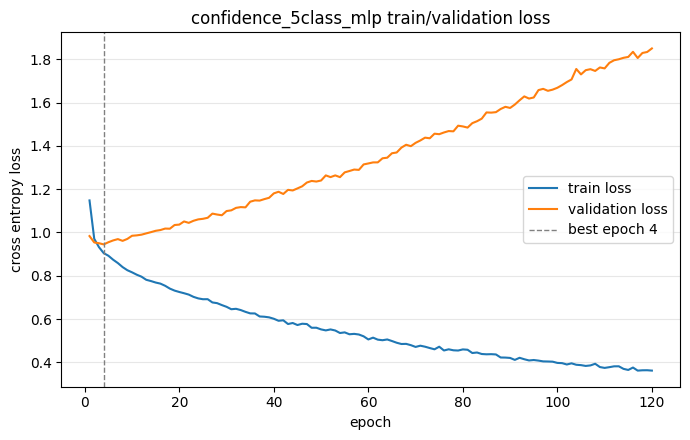

confidence_5class_mlp best_epoch: 4 best_val_loss: 0.944841


,task,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,best_epoch,best_val_loss
0,confidence_5class_mlp,0.5937,0.4366,0.2843,0.2969,0.5684,0.5937,0.5476,0.4629,4,0.9448


,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0,1,9,6,0
true_2,0,11,38,63,0
true_3,0,4,183,303,2
true_4,0,4,123,770,10
true_5,0,0,3,102,12


              precision    recall  f1-score   support

confidence_1       0.00      0.00      0.00        16
confidence_2       0.55      0.10      0.17       112
confidence_3       0.51      0.37      0.43       492
confidence_4       0.62      0.85      0.72       907
confidence_5       0.50      0.10      0.17       117

    accuracy                           0.59      1644
   macro avg       0.44      0.28      0.30      1644
weighted avg       0.57      0.59      0.55      1644



In [5]:
y5 = (df['confidence'].values.astype(np.int64) - 1)
y5_train = y5[train_idx]
y5_val = y5[val_idx]
y5_test = y5[test_idx]

model_5class, history_5class, best_5class = train_mlp(
    task_name='confidence_5class_mlp',
    X_train=X_train,
    y_train=y5_train,
    X_val=X_val,
    y_val=y5_val,
    output_dim=5,
)

pred5_zero, prob5 = predict(model_5class, X_test)
pred5 = pred5_zero + 1
true5 = y5_test + 1

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(true5, pred5, labels=LABELS, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(true5, pred5, labels=LABELS, average='weighted', zero_division=0)

metrics_5class = pd.DataFrame([
    {
        'task': 'confidence_5class_mlp',
        'accuracy': accuracy_score(true5, pred5),
        'macro_precision': p_macro,
        'macro_recall': r_macro,
        'macro_f1': f1_macro,
        'weighted_precision': p_weighted,
        'weighted_recall': r_weighted,
        'weighted_f1': f1_weighted,
        'mae': mean_absolute_error(true5, pred5),
        'best_epoch': best_5class['best_epoch'],
        'best_val_loss': best_5class['best_val_loss'],
    }
])

cm_5class = pd.DataFrame(
    confusion_matrix(true5, pred5, labels=LABELS),
    index=[f'true_{x}' for x in LABELS],
    columns=[f'pred_{x}' for x in LABELS],
)

report_5class_text = classification_report(
    true5,
    pred5,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    zero_division=0,
)
report_5class_dict = classification_report(
    true5,
    pred5,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    output_dict=True,
    zero_division=0,
)

metrics_5class.to_csv(OUT_DIR / 'confidence_5class_metrics.csv', index=False, encoding='utf-8-sig')
cm_5class.to_csv(OUT_DIR / 'confidence_5class_confusion_matrix.csv', encoding='utf-8-sig')
(OUT_DIR / 'confidence_5class_classification_report.txt').write_text(report_5class_text, encoding='utf-8')
pd.DataFrame(report_5class_dict).T.to_csv(OUT_DIR / 'confidence_5class_classification_report.csv', encoding='utf-8-sig')

pred_5class_df = pd.DataFrame({
    'sound_id': df.loc[test_idx, 'sound_id'].values,
    'true_confidence': true5,
    'pred_confidence': pred5,
})
for i in range(5):
    pred_5class_df[f'prob_confidence_{i + 1}'] = prob5[:, i]
pred_5class_df.to_csv(OUT_DIR / 'confidence_5class_test_predictions.csv', index=False, encoding='utf-8-sig')
torch.save({
    'model_state_dict': {k: v.detach().cpu() for k, v in model_5class.state_dict().items()},
    'feature_description': FEATURE_DESCRIPTION,
    'input_dim': int(X_full.shape[1]),
    'output_dim': 5,
    'labels': LABELS,
    'scalar_feature_cols': SCALAR_FEATURE_COLS,
    'class_categories': class_categories,
}, OUT_DIR / 'confidence_5class_mlp.pt')

display(metrics_5class.round(4))
display(cm_5class)
print(report_5class_text)

## 5. Binary confidence classification: 123 vs 45

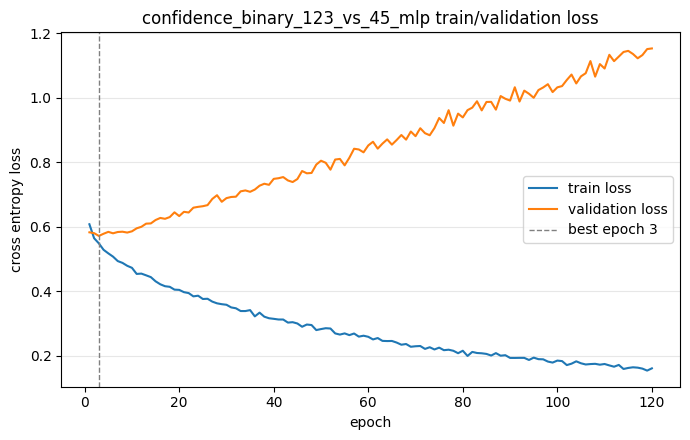

confidence_binary_123_vs_45_mlp best_epoch: 3 best_val_loss: 0.572118


,task,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,best_epoch,best_val_loss
0,confidence_binary_123_vs_45_mlp,0.7032,0.683,0.6656,0.6702,0.6958,0.7032,0.6958,0.2968,3,0.5721


,pred_123,pred_45
true_123,318,302
true_45,186,838


                precision    recall  f1-score   support

confidence_123       0.63      0.51      0.57       620
 confidence_45       0.74      0.82      0.77      1024

      accuracy                           0.70      1644
     macro avg       0.68      0.67      0.67      1644
  weighted avg       0.70      0.70      0.70      1644



In [6]:
yb = df['binary_confidence'].values.astype(np.int64)
yb_train = yb[train_idx]
yb_val = yb[val_idx]
yb_test = yb[test_idx]

model_binary, history_binary, best_binary = train_mlp(
    task_name='confidence_binary_123_vs_45_mlp',
    X_train=X_train,
    y_train=yb_train,
    X_val=X_val,
    y_val=yb_val,
    output_dim=2,
)

pred_binary, prob_binary = predict(model_binary, X_test)
true_binary = yb_test

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(true_binary, pred_binary, labels=[0, 1], average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(true_binary, pred_binary, labels=[0, 1], average='weighted', zero_division=0)

metrics_binary = pd.DataFrame([
    {
        'task': 'confidence_binary_123_vs_45_mlp',
        'accuracy': accuracy_score(true_binary, pred_binary),
        'macro_precision': p_macro,
        'macro_recall': r_macro,
        'macro_f1': f1_macro,
        'weighted_precision': p_weighted,
        'weighted_recall': r_weighted,
        'weighted_f1': f1_weighted,
        'mae': mean_absolute_error(true_binary, pred_binary),
        'best_epoch': best_binary['best_epoch'],
        'best_val_loss': best_binary['best_val_loss'],
    }
])

cm_binary = pd.DataFrame(
    confusion_matrix(true_binary, pred_binary, labels=[0, 1]),
    index=['true_123', 'true_45'],
    columns=['pred_123', 'pred_45'],
)

report_binary_text = classification_report(
    true_binary,
    pred_binary,
    labels=[0, 1],
    target_names=['confidence_123', 'confidence_45'],
    zero_division=0,
)
report_binary_dict = classification_report(
    true_binary,
    pred_binary,
    labels=[0, 1],
    target_names=['confidence_123', 'confidence_45'],
    output_dict=True,
    zero_division=0,
)

metrics_binary.to_csv(OUT_DIR / 'confidence_binary_123_vs_45_metrics.csv', index=False, encoding='utf-8-sig')
cm_binary.to_csv(OUT_DIR / 'confidence_binary_123_vs_45_confusion_matrix.csv', encoding='utf-8-sig')
(OUT_DIR / 'confidence_binary_123_vs_45_classification_report.txt').write_text(report_binary_text, encoding='utf-8')
pd.DataFrame(report_binary_dict).T.to_csv(OUT_DIR / 'confidence_binary_123_vs_45_classification_report.csv', encoding='utf-8-sig')

pred_binary_df = pd.DataFrame({
    'sound_id': df.loc[test_idx, 'sound_id'].values,
    'true_binary_confidence': true_binary,
    'pred_binary_confidence': pred_binary,
    'prob_123': prob_binary[:, 0],
    'prob_45': prob_binary[:, 1],
})
pred_binary_df.to_csv(OUT_DIR / 'confidence_binary_123_vs_45_test_predictions.csv', index=False, encoding='utf-8-sig')
torch.save({
    'model_state_dict': {k: v.detach().cpu() for k, v in model_binary.state_dict().items()},
    'feature_description': FEATURE_DESCRIPTION,
    'input_dim': int(X_full.shape[1]),
    'output_dim': 2,
    'labels': {'0': 'confidence_123', '1': 'confidence_45'},
    'scalar_feature_cols': SCALAR_FEATURE_COLS,
    'class_categories': class_categories,
}, OUT_DIR / 'confidence_binary_123_vs_45_mlp.pt')

display(metrics_binary.round(4))
display(cm_binary)
print(report_binary_text)

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0,1,9,6,0
true_2,0,11,38,63,0
true_3,0,4,183,303,2
true_4,0,4,123,770,10
true_5,0,0,3,102,12


              precision    recall  f1-score   support

confidence_1     0.0000    0.0000    0.0000        16
confidence_2     0.5500    0.0982    0.1667       112
confidence_3     0.5140    0.3720    0.4316       492
confidence_4     0.6190    0.8490    0.7159       907
confidence_5     0.5000    0.1026    0.1702       117

    accuracy                         0.5937      1644
   macro avg     0.4366    0.2843    0.2969      1644
weighted avg     0.5684    0.5937    0.5476      1644



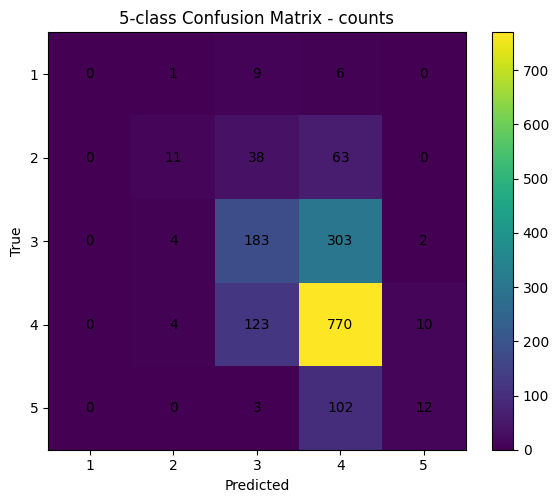

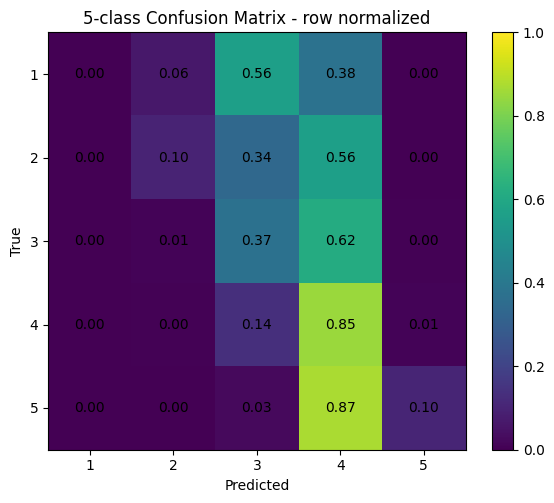

,pred_123,pred_45
true_123,318,302
true_45,186,838


                precision    recall  f1-score   support

confidence_123     0.6310    0.5129    0.5658       620
 confidence_45     0.7351    0.8184    0.7745      1024

      accuracy                         0.7032      1644
     macro avg     0.6830    0.6656    0.6702      1644
  weighted avg     0.6958    0.7032    0.6958      1644



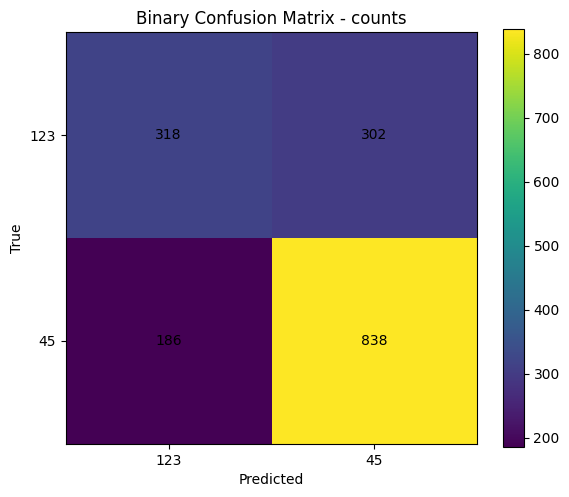

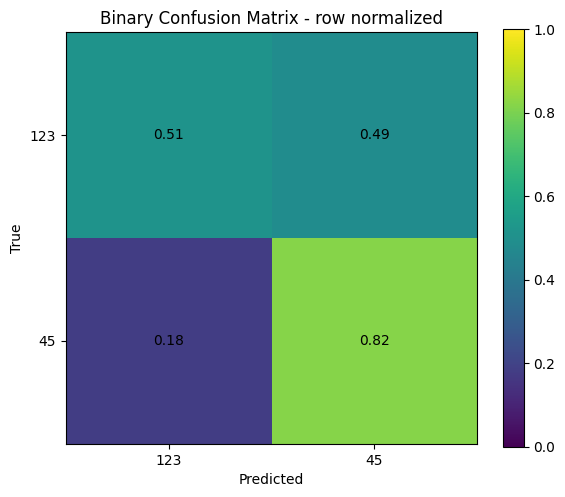

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(cm, x_labels, y_labels, title, save_path=None, normalize=True):
    cm = np.asarray(cm)
    if normalize:
        cm_plot = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        fmt = ".2f"
        vmin, vmax = 0, 1
    else:
        cm_plot = cm
        fmt = "d"
        vmin, vmax = None, None

    plt.figure(figsize=(6, 5))
    plt.imshow(cm_plot, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(x_labels)), x_labels)
    plt.yticks(range(len(y_labels)), y_labels)

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            value = cm_plot[i, j]
            text = f"{value:{fmt}}" if normalize else f"{int(value)}"
            plt.text(j, i, text, ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=180)

    plt.show()
    

# 5-class confidence confusion matrix
labels_5 = [1, 2, 3, 4, 5]

cm_5class = confusion_matrix(true5, pred5, labels=labels_5)
cm_5class_df = pd.DataFrame(
    cm_5class,
    index=[f"true_{x}" for x in labels_5],
    columns=[f"pred_{x}" for x in labels_5],
)

display(cm_5class_df)

print(classification_report(
    true5,
    pred5,
    labels=labels_5,
    target_names=[f"confidence_{x}" for x in labels_5],
    digits=4,
    zero_division=0,
))

plot_confusion_matrix(
    cm_5class,
    x_labels=labels_5,
    y_labels=labels_5,
    title="5-class Confusion Matrix - counts",
    normalize=False,
)

plot_confusion_matrix(
    cm_5class,
    x_labels=labels_5,
    y_labels=labels_5,
    title="5-class Confusion Matrix - row normalized",
    save_path=PLOT_DIR / "confidence_5class_confusion_matrix_row_normalized.png",
    normalize=True,
)

# Binary confidence confusion matrix
labels_binary = [0, 1]
binary_names = ["123", "45"]

cm_binary = confusion_matrix(true_binary, pred_binary, labels=labels_binary)
cm_binary_df = pd.DataFrame(
    cm_binary,
    index=["true_123", "true_45"],
    columns=["pred_123", "pred_45"],
)

display(cm_binary_df)

print(classification_report(
    true_binary,
    pred_binary,
    labels=labels_binary,
    target_names=["confidence_123", "confidence_45"],
    digits=4,
    zero_division=0,
))

plot_confusion_matrix(
    cm_binary,
    x_labels=binary_names,
    y_labels=binary_names,
    title="Binary Confusion Matrix - counts",
    normalize=False,
)

plot_confusion_matrix(
    cm_binary,
    x_labels=binary_names,
    y_labels=binary_names,
    title="Binary Confusion Matrix - row normalized",
    save_path=PLOT_DIR / "confidence_binary_123_vs_45_confusion_matrix_row_normalized.png",
    normalize=True,
)

## 6. Summary 저장

In [8]:
all_metrics = pd.concat([metrics_5class, metrics_binary], ignore_index=True)
all_metrics.to_csv(OUT_DIR / 'all_mlp_metrics.csv', index=False, encoding='utf-8-sig')

def table_text(table, index=False):
    return table.round(4).to_string(index=index)

report_lines = []
report_lines.append('# Embedding Feature MLP Confidence Classification Report')
report_lines.append('')
report_lines.append('## Input features')
report_lines.append(f'- {FEATURE_DESCRIPTION}')
report_lines.append(f'- audio embedding dim: {audio_emb.shape[1]}')
report_lines.append(f'- text embedding dim: {text_emb.shape[1]}')
report_lines.append(f'- class one-hot dim: {class_onehot.shape[1]}')
report_lines.append(f'- scalar feature dim: {scalar_features.shape[1]}')
for col in SCALAR_FEATURE_COLS:
    report_lines.append(f'  - {col}')
report_lines.append(f'- total input dim: {X_full.shape[1]}')
report_lines.append('')
report_lines.append('## Metrics')
report_lines.append('```text')
report_lines.append(table_text(all_metrics, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## 5-class confusion matrix')
report_lines.append('```text')
report_lines.append(table_text(cm_5class, index=True))
report_lines.append('```')
report_lines.append('')
report_lines.append('## 5-class classification report')
report_lines.append('```text')
report_lines.append(report_5class_text)
report_lines.append('```')
report_lines.append('')
report_lines.append('## Binary confusion matrix')
report_lines.append('```text')
report_lines.append(table_text(cm_binary, index=True))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Binary classification report')
report_lines.append('```text')
report_lines.append(report_binary_text)
report_lines.append('```')

summary_json = {
    'feature_description': FEATURE_DESCRIPTION,
    'audio_embedding_dim': int(audio_emb.shape[1]),
    'text_embedding_dim': int(text_emb.shape[1]),
    'class_onehot_dim': int(class_onehot.shape[1]),
    'scalar_feature_dim': int(scalar_features.shape[1]),
    'scalar_feature_cols': SCALAR_FEATURE_COLS,
    'total_input_dim': int(X_full.shape[1]),
    'output_dir': str(OUT_DIR),
    'metrics': json.loads(all_metrics.to_json(orient='records')),
}

(OUT_DIR / 'summary.json').write_text(json.dumps(summary_json, indent=2, ensure_ascii=False), encoding='utf-8')
(OUT_DIR / 'mlp_confidence_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

print('saved:', OUT_DIR / 'mlp_confidence_report.md')
print('saved:', OUT_DIR / 'summary.json')
display(all_metrics.round(4))

saved: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\mlp_embedding_plus_similarity_confidence_outputs\mlp_confidence_report.md
saved: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\mlp_embedding_plus_similarity_confidence_outputs\summary.json


,task,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mae,best_epoch,best_val_loss
0,confidence_5class_mlp,0.5937,0.4366,0.2843,0.2969,0.5684,0.5937,0.5476,0.4629,4,0.9448
1,confidence_binary_123_vs_45_mlp,0.7032,0.6830,0.6656,0.6702,0.6958,0.7032,0.6958,0.2968,3,0.5721
